### 회귀(Regression)
 - 데이터 값이 평균과 같은 일정한 값으로 돌아가려는 경향을 이용한 통계학 기법이다.
 - 독립변수와 종속변수 간의 상관관계를 모델링하는 기법이다.
 - 1개의 독립변수 : 단일회귀(선형 단위회귀), 여러개의 독립변수 : 다중회귀 (비선형 회귀)

### 회귀의 어원###
 유전학자 프란시스 골턴은 유전의 법칙에 연구하다 회귀의 법칙을 발견하였다. 그는 아들의 키를 아버지의 키와 비교할 경우, 아버지의 키가 아무리 크다고 할지라도 아들의 키는 모집단(아들세대)의 평균으로 접근하려는 경향을 발견했다. 즉, 키가 큰 아버지는 자신보다 키가 좀 더 작은 아들을 가지며, 키가 작은 아버지는 자신보다 키가 좀 거 큰 아들을 갖는 경향을 발견했다. 골턴은 이러한 현상을 평균으로 회귀(regression toward mean)라고 했다.
이처럼 회귀분석의 회귀란 평균으로 되돌아 간다는 의미이다.

### 1. 데이터 정의

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

(5, 1)
(5, 1)


<Axes: xlabel='X', ylabel='y'>

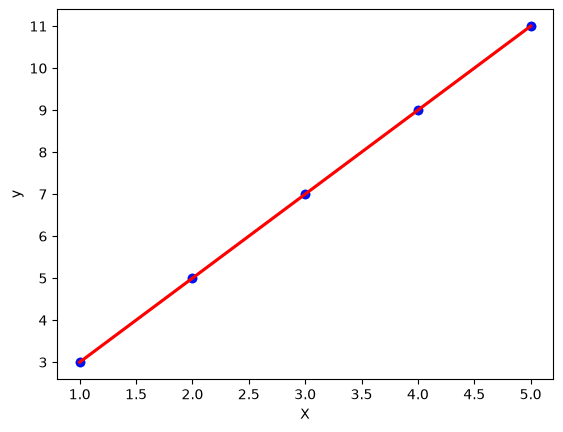

In [2]:
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([3, 5, 7, 9, 11]).reshape(-1, 1)

print(X.shape)
print(y.shape)

plt.scatter(X, y)

pd_X = pd.DataFrame(X, columns=['X'])
pd_y = pd.DataFrame(y, columns=['y'])
pd_df = pd.concat([pd_X, pd_y], axis=1)
sns.regplot(data = pd_df, x='X', y='y', line_kws={'color':'red'}, scatter_kws={'color':'blue'})




- 가설함수(Hypothesis)  
  H(x)=  Wx + b


- 오차함수  loss(W,B) 의 정의  
$loss(W,B) = L(g(W,B)) = MSE = \frac{1}{n}\sum_{i=1}^{n} (Y_i-\hat{Y_i})^2$

- 오차 함수의 W, b에 대한 도함수 (편미분)
  - 제곱오차(SE)   
$f = (y - \hat{y})^2$
  - 가중치:weight(기계학습) = 회귀계수:coefficient(통계)       
$\frac{df}{dW} =  \frac{d}{dW}  \frac{1}{2}(y - \hat{y})^2 =   -X * (y - \hat{y})$    
  - 편향:bias(기계학습) = 절편:intercept(통계)       
$\frac{df}{db} = \frac{d}{db}  \frac{1}{2}(y - \hat{y})^2 =   - (y - \hat{y})$

- 경사하강법(gradient descent) 적용  
  - 가중치 업데이트  
$W = W - \alpha(\frac{df}{dW})$
  - 절편 업데이트   
$b = b - \alpha(\frac{df}{db})$)

### 단순선형회귀

In [3]:
import numpy as np

# 목표 타깃: y = 2X + 1
learning_rate = 0.01

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # (5, 1)
y = np.array([3, 5, 7, 9, 11]).reshape(-1, 1) # (5, 1)

W = np.zeros((1, 1))  # 기울기 0으로 초기화
b = np.zeros((1, 1))  # 절편 0으로 초기화

# 1. 순전파 및 손실(MSE) 계산 함수
def linear_forward(X, y, W, b):
    y_pred = np.dot(X, W) + b   # (5, 1)
    cost = np.sum(np.square(y - y_pred)) / len(y)
    return y_pred, cost

y_pred, cost = linear_forward(X, y, W, b)
print('==== 학습 전 (Before) ====')
print(f'W: {W[0,0]:.4f}, b: {b[0,0]:.4f}, cost: {cost:.4f}')

# 2. 기울기(Gradient) 계산 함수
def loss_gradient(X, y, W, b):
    N = len(y)
    y_pred = np.dot(X, W) + b

    # Error = (y - y_pred)
    # MSE 미분값: dJ/dW = -(2/N) * X^T * (y - y_pred)
    #            dJ/db = -(2/N) * sum(y - y_pred)
    de_W = 1 * np.dot(X.T, y - y_pred)
    de_b = 1 * np.sum(y - y_pred, axis=0, keepdims=True)

    # [수정] MSE 미분 계수인 (2 / N)을 곱해줍니다.
    de_W = (1 / N) * de_W
    de_b = (1 / N) * de_b

    return de_W, de_b

# 3. 경사하강법 학습 진행 (반복 횟수: 3000회)
epochs = 5000
for i in range(epochs):
    de_W, de_b = loss_gradient(X, y, W, b)

    # 경사하강법 파라미터 업데이트
    W = W + learning_rate * de_W
    b = b + learning_rate * de_b

y_pred, cost = linear_forward(X, y, W, b)
print('\n==== 학습 후 (After) ====')
print(f'W: {W[0,0]:.4f} (목표: 2.0000)')
print(f'b: {b[0,0]:.4f} (목표: 1.0000)')
print(f'cost: {cost:.6f}')

==== 학습 전 (Before) ====
W: 0.0000, b: 0.0000, cost: 57.0000

==== 학습 후 (After) ====
W: 2.0000 (목표: 2.0000)
b: 0.9999 (목표: 1.0000)
cost: 0.000000


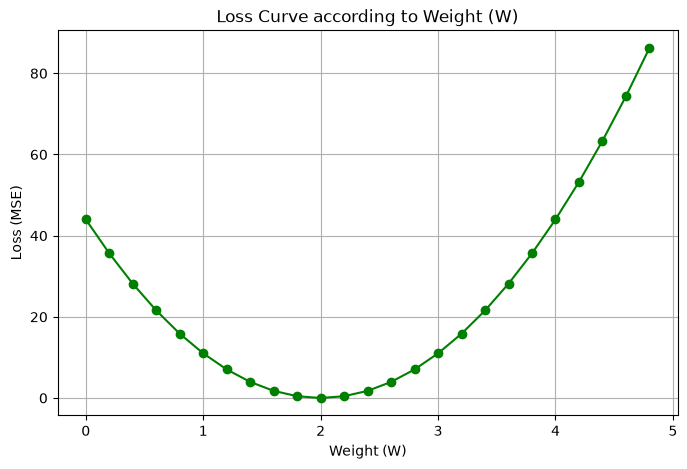

In [4]:
# 가중치 W의 후보군 (0부터 5미만 0.2 간격)
weights = np.arange(0, 5 , 0.2)

loss_array = []
for weight in weights:
  #  weight 스칼라 값을 (1, 1) 형태의 2차원 배열로 변환하여 전달
  W_shape = np.array([[weight]])
  _, loss = linear_forward(X, y, W_shape, b)
  loss_array.append(loss)

# print(loss_array)
print()

# 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(weights, loss_array, marker='o', color='green', linestyle='-')
plt.title('Loss Curve according to Weight (W)')
plt.xlabel('Weight (W)')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

```
[그래프 결과 해석[]
- 위 코드를 실행하면 W = 2.0 부근에서 Loss(오차)가 0으로 최소가 되는 매끄러운 U자형 포물선 그래프가 출력됩니다.
- 경사하강법은 바로 이 포물선의 아무 위치(예: W=0)에서 시작하여, 기울기를 따라 최저점인 W=2.0을 향해 굴러 내려가는 과정이라는 점을 시각적으로 바로 확인할 수 있다.
```

In [5]:
def predict(test):
  return W*test+b

predict(7)

array([[15.0000824]])

### 다중선형회귀(Multivariate Linear Regression)
- 변수(feature)가 2개 이상인 데이터의 결과를 예측하는 것

In [6]:
import numpy as np

# 1. 데이터 정의
X = np.array([
        [2, 4, 6, 8, 10], [0, 4, 2, 3, 4]
    ]).T  # (5, 2)
y = np.array([81, 93, 91, 97, 98]).reshape(-1, 1)    # (5, 1)


# 학습률 및 에포크 조정 (충분한 수렴을 위해 10만 회 수행)
learning_rate = 0.003
epochs = 100000

W = np.zeros((2, 1))
b = np.zeros((1, 1))

def loss_gradient(X, y, W, b):
    N = len(y)
    y_pred = np.dot(X, W) + b

    de_W = (1 / N) * np.dot(X.T, y - y_pred)
    de_b = (1 / N) * np.sum(y - y_pred, axis=0, keepdims=True)

    return de_W, de_b

# 2. 경사하강법 진행
for i in range(epochs):
    de_dW, de_db = loss_gradient(X, y, W, b)

    W = W + learning_rate * de_dW
    b = b + learning_rate * de_db

# 3. 최종 예측값 및 R2 계산
y_pred = np.dot(X, W) + b

ss_res = np.sum((y.flatten() - y_pred.flatten()) ** 2)
ss_tot = np.sum((y.flatten() - np.mean(y.flatten())) ** 2)


r2 = 1 - (ss_res / ss_tot)

print(f"추정된 W:\n{W}")
print(f"추정된 b: {b[0,0]:.4f}")
print(f"올바른 R2 Score: {r2:.4f}")

추정된 W:
[[1.1       ]
 [2.28571429]]
추정된 b: 79.4571
올바른 R2 Score: 0.9637


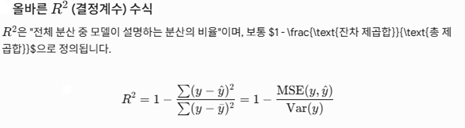

직접 R^2 (결정계수) 검증하기

In [7]:
import numpy as np

# 1. 수식을 이용한 직접 계산 (가장 권장)
ss_res = np.sum((y.flatten() - y_pred.flatten()) ** 2)  # 잔차 제곱합 (Residual Sum of Squares)
ss_tot = np.sum((y.flatten() - np.mean(y.flatten())) ** 2)  # 총 제곱합 (Total Sum of Squares)

r2 = 1 - (ss_res / ss_tot)
print(f"올바른 R2 Score: {r2:.4f}")

올바른 R2 Score: 0.9637


사이킷런(scikit-learn) 라이브러리로 검증하기

In [8]:
from sklearn.metrics import r2_score

# Flatten할 필요 없이 바로 넣어도 내부적으로 처리해 줍니다.
r2 = r2_score(y, y_pred)
print(f"Scikit-learn R2 Score: {r2:.4f}")

Scikit-learn R2 Score: 0.9637


각 컬럼별로 주택가격에 미치는 영향도를 조사

* CRIM: 지역별 범죄 발생률  
* ZN: 25,000평방피트를 초과하는 거주 지역의 비율
* NDUS: 비상업 지역 넓이 비율
* CHAS: 찰스강에 대한 더미 변수(강의 경계에 위치한 경우는 1, 아니면 0)
* NOX: 일산화질소 농도
* RM: 거주할 수 있는 방 개수
* AGE: 1940년 이전에 건축된 소유 주택의 비율
* DIS: 5개 주요 고용센터까지의 가중 거리
* RAD: 고속도로 접근 용이도
* TAX: 10,000달러당 재산세율
* PTRATIO: 지역의 교사와 학생 수 비율
* B: 지역의 흑인 거주 비율
* LSTAT: 하위 계층의 비율
* MEDV: 본인 소유의 주택 가격(중앙값)

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
dtypes: category(2), float64(11)
memory usage: 44.7 KB
None
506
row col 0 0
row col 0 1
row col 0 2
row col 0 3
row col 1 0
row col 1 1
row col 1 2


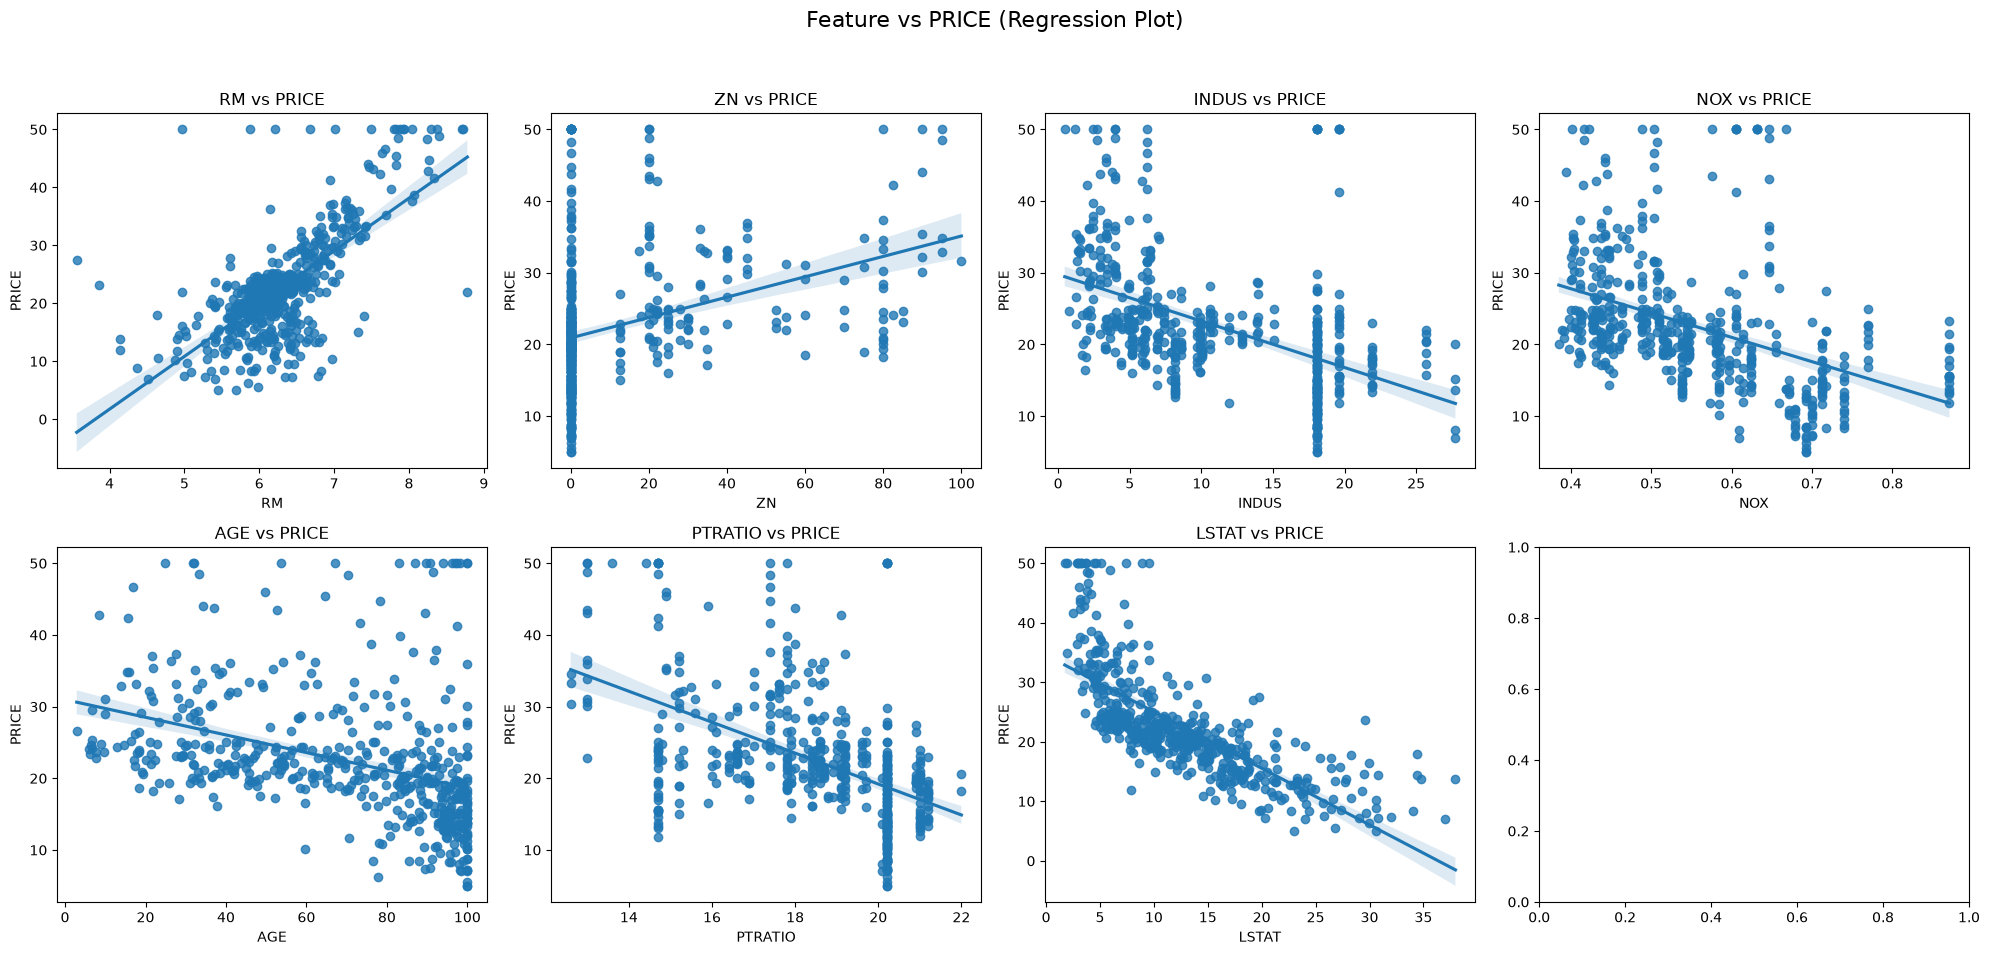

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

# 1. Boston 데이터 로드
X, y = datasets.fetch_openml('boston', version=1, as_frame=True, return_X_y=True)
print(X.info())
print(len(X))
# 2. 데이터프레임 구성
bostonDF = X.copy()

bostonDF['PRICE'] = y.astype(float)  # y를 float로 변환
#print(len(bostonDF['PRICE']))



# 3. 시각화할 특성 목록
lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE', 'PTRATIO', 'LSTAT']

# subplot을 먼저 정의해야 함!
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
fig.suptitle("Feature vs PRICE (Regression Plot)", fontsize=16)

# 4. 각 특성에 대해 regplot 그리기
for i, feature in enumerate(lm_features):
    row = int(i / 4)
    col = i % 4
    print('row col', row, col)
    sns.regplot(data=bostonDF, x=feature, y='PRICE', ax=axes[row][col])
    axes[row][col].set_title(f'{feature} vs PRICE')

# sns.regplot(data=bostonDF, x='RM', y='PRICE', ax=axes[0][0])
# sns.regplot(data=bostonDF, x='ZN', y='PRICE', ax=axes[0][1])
# 5. 여백 조정
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


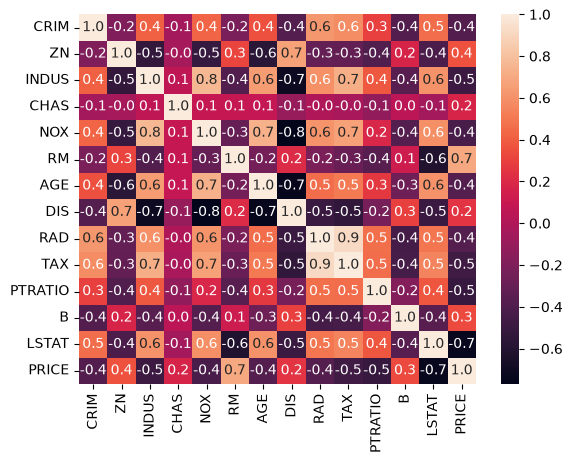

In [10]:
corr_matrix = bostonDF.corr()
sns.heatmap(data=corr_matrix, fmt='.1f', annot=True)
plt.show()

학습과 테스트 데이터 세트로 분리하고 학습/예측/평가 수행

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression  # LinearRegression(회귀) LogisticRegression(분류)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

print(bostonDF.shape)
print("------------------------------------------------------------")
# CHAS RAD
print(bostonDF['CHAS'].value_counts()) # 0 1
print("------------------------------------------------------------")
print(bostonDF['RAD'].value_counts())  # 1
print("------------------------------------------------------------")

# train과 test을 70:30 비율로 나눔
# TypeError: can't multiply sequence by non-int of type 'float'
#X_train, X_test, y_train, y_test =  train_test_split(bostonDF, bostonDF.iloc[:,-1],  test_size=0.3, random_state=156)

# boston_encoded = pd.get_dummies(bostonDF, columns=['CHAS', 'RAD'])
boston_encoded = pd.get_dummies(bostonDF, columns=['CHAS', 'RAD'], drop_first=True)
boston_train = boston_encoded[[col for col in boston_encoded if col != "PRICE"]]
X_train, X_test, y_train, y_test =  train_test_split(boston_train, bostonDF.iloc[:,-1],  test_size=0.3, random_state=156)

lr = LinearRegression()
model = lr.fit(X_train, y_train)
print('coef_:', len(model.coef_))
print("------------------------------------------------------------")
print('inter_:', model.intercept_)
print("------------------------------------------------------------")
y_preds = lr.predict(X_test)

mse = mean_squared_error(y_test, y_preds)
print('MSE : {0:.3f}'.format(mse))
print("------------------------------------------------------------")
# r2_score()의 결과는 0부터 1까지 나올 수 있으며 1이면 상관이 높다는 의미이므로 훈련이 잘 되어여 있다.
# 1에 가까울 수록 좋은 것다.
print('r2_score : {0:.10f}'.format(r2_score(y_test, y_preds)))  # r2_score(테스트 실제정답, 테스트 예측값)



(506, 14)
------------------------------------------------------------
CHAS
0    471
1     35
Name: count, dtype: int64
------------------------------------------------------------
RAD
24    132
5     115
4     110
3      38
6      26
2      24
8      24
1      20
7      17
Name: count, dtype: int64
------------------------------------------------------------
coef_: 20
------------------------------------------------------------
inter_: 42.089311461961614
------------------------------------------------------------
MSE : 17.517
------------------------------------------------------------
r2_score : 0.7541352964


In [12]:
from sklearn.datasets import load_diabetes

df = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.3)

lr = LinearRegression()
model = lr.fit(X_train, y_train)
#print('coef_:', model.coef_)
#print('inter_:', model.intercept_)

y_preds = lr.predict(X_test)

mse = mean_squared_error(y_test, y_preds)
print('MSE : {0:.3f}'.format(mse))
# r2_score()의 결과는 0부터 1까지 나올 수 있으며 1이면 상관이 높다는 의미이므로 훈련이 잘 되어여 있다.
# 1에 가까울 수록 좋은 것다.
print('r2_score : {0:.10f}'.format(r2_score(y_test, y_preds)))  # r2_score(테스트 실제정답, 테스트 예측값)

MSE : 3081.477
r2_score : 0.4965331365
